In [1]:
%pip install jupysql duckdb duckdb-engine --quiet

%load_ext sql
%sql duckdb:///:memory:

Note: you may need to restart the kernel to use updated packages.


Connecting to 'duckdb:///:memory:'

In [2]:
%%sql
create table bookings as select * from read_csv_auto('bookings.csv');
create table clients as select * from read_csv_auto('clients.csv');

Running query in 'duckdb:///:memory:'

Count
50


In [3]:
%%sql task_1 <<
select
    subproduct,
    extract(month from booking_date) as month,
    round(sum(amount_rub),2) as gmv,
    count(*) as bookings_count
from bookings
where status = 'confirmed'
group by subproduct, month
order by subproduct, month

Running query in 'duckdb:///:memory:'

In [4]:
df_task_1 = task_1.DataFrame()
df_task_1

,subproduct,month,gmv,bookings_count
0,avia,1,3465491.28,43
1,avia,2,4821583.41,60
2,avia,3,5966560.92,76
3,avia,4,4545435.50,59
4,avia,5,4624326.74,67
5,avia,6,7474322.49,104
6,avia,7,4638029.35,58
7,avia,8,3665833.59,51
8,avia,9,2915620.05,30
9,avia,10,3069933.92,35


In [5]:
%%sql 
with subproduct_month_stats as (
    select
        subproduct,
        extract(month from booking_date) as month,
        sum(amount_rub) as gmv,
        count(*) as bookings_count
    from bookings
    where status = 'confirmed'
    group by subproduct, month
)

select 
    subproduct,
    round(sum(gmv),2) as sum_gmv
from subproduct_month_stats
group by subproduct
order by sum_gmv desc

Running query in 'duckdb:///:memory:'

subproduct,sum_gmv
avia,51305843.4
hotel,28495450.26
train,4534020.63
taxi,367063.63


In [6]:
%%sql task_1_season << 
with subproduct_month_stats as (
    select
        subproduct,
        extract(month from booking_date) as month,
        round(sum(amount_rub),2) as gmv,
        count(*) as bookings_count
    from bookings
    where status = 'confirmed'
    group by subproduct, month
)

select 
    subproduct,
    month,
    round(sum(gmv),2) as sum_gmv
from subproduct_month_stats
group by subproduct, month
order by subproduct, month

Running query in 'duckdb:///:memory:'

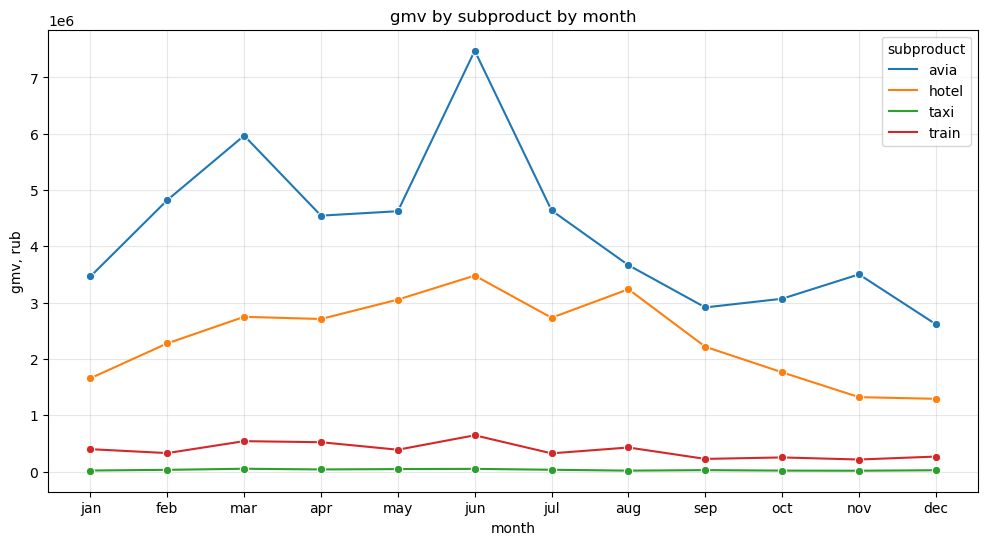

In [7]:
df_task_1_season = task_1_season.DataFrame()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

month_map = {
    1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr',
    5: 'may', 6: 'jun', 7: 'jul', 8: 'aug',
    9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}

df_task_1_season['month_name'] = df_task_1_season['month'].map(month_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_task_1_season,
    x='month_name',
    y='sum_gmv',
    hue='subproduct',
    marker='o'
)

plt.title('gmv by subproduct by month')
plt.xlabel('month')
plt.ylabel('gmv, rub')
plt.grid(alpha=0.3)
plt.show()

/var/folders/_v/q0x0ct1d7vsccvqk4j4jzkzw0000gn/T/ipykernel_57913/3099172154.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxi_df['month_name'] = taxi_df['month'].map(month_map)


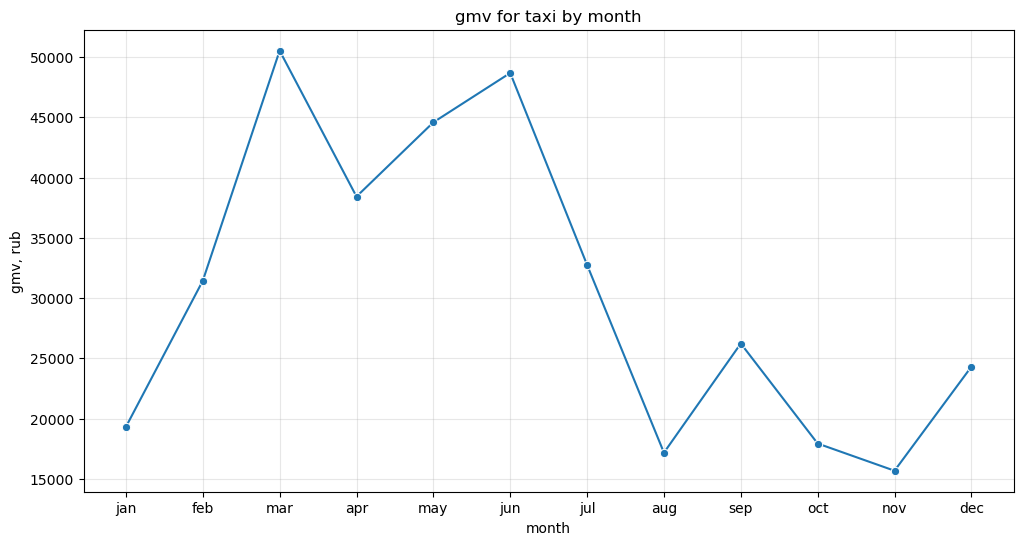

In [8]:
taxi_df = df_task_1_season[df_task_1_season['subproduct'] == 'taxi']

month_map = {
    1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr',
    5: 'may', 6: 'jun', 7: 'jul', 8: 'aug',
    9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}

taxi_df['month_name'] = taxi_df['month'].map(month_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=taxi_df,
    x='month_name',
    y='sum_gmv',
    marker='o'
)

plt.title('gmv for taxi by month')
plt.xlabel('month')
plt.ylabel('gmv, rub')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
Наибольший оборот генерирует avia: 51305843.4 RUB

Пик оборота по всем субпродуктам, кроме такси, приходится на июнь.
Для такси приведен отдельный график. 
На нем видно, что пики у такси приходятся на весенне-летний период. Аналогичная ситуация и у остальных субпродуктов.